# Laboratorio 8 — Comparación entre Pearson y Spearman

## Objetivo

Comparar los coeficientes de correlación de **Pearson** y **Spearman** para analizar relaciones entre variables numéricas.

Durante el laboratorio se observará primero el comportamiento gráfico de las variables y posteriormente se calcularán ambos coeficientes para determinar qué información aporta cada medida.

## Conjunto de datos

Continuaremos utilizando el conjunto de datos **Auto MPG**, empleado en el laboratorio anterior.

El archivo utilizado en Google Colab es:

`/content/auto-mpg.csv`

Cada observación representa un automóvil y contiene información sobre características como rendimiento de combustible, peso, potencia, cilindrada y aceleración.

## 1. Preparación del conjunto de datos

Antes de calcular las correlaciones, verificaremos los tipos de datos del conjunto **Auto MPG**.

Aunque `horsepower` representa la potencia del automóvil y debería ser una variable numérica, el dataset contiene algunos registros con el carácter `?`.

Por esta razón, Pandas interpreta inicialmente la columna `horsepower` como una variable de tipo `object`.

Antes de continuar con el análisis debemos identificar y tratar estos registros.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/auto-mpg.csv")
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


## 2. Identificación de valores no numéricos
Aunque `horsepower` representa una variable cuantitativa, Pandas la identificó como `object`.
Vamos a identificar los registros de esta columna que no pueden ser interpretados como valores numéricos.

In [2]:
valores_no_numericos = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
).isna()
df[valores_no_numericos]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


### 2.1 Análisis del resultado

**Pregunta:** ¿Qué valor está provocando que Pandas interprete la variable `horsepower` como `object` y cuántas observaciones presentan este problema?

## 3. Preparación de la variable `horsepower`

Para utilizar `horsepower` en los análisis estadísticos, convertiremos la variable a formato numérico.

Los valores que no puedan convertirse serán reemplazados por `NaN`. Posteriormente, las observaciones con valores faltantes en esta variable serán excluidas del análisis.

In [3]:
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)
df = df.dropna(subset=["horsepower"]).copy()
print("Número de observaciones:", len(df))
print("Tipo de dato de horsepower:", df["horsepower"].dtype)

Número de observaciones: 392
Tipo de dato de horsepower: float64


## 4. Comparación entre Pearson y Spearman

Comenzaremos analizando la relación entre el **peso del automóvil (`weight`)** y su **rendimiento de combustible (`mpg`)**.

Antes de calcular los coeficientes de correlación, observaremos el diagrama de dispersión.

Esto permitirá identificar visualmente el patrón de la relación y posteriormente comparar los resultados obtenidos mediante **Pearson** y **Spearman**.

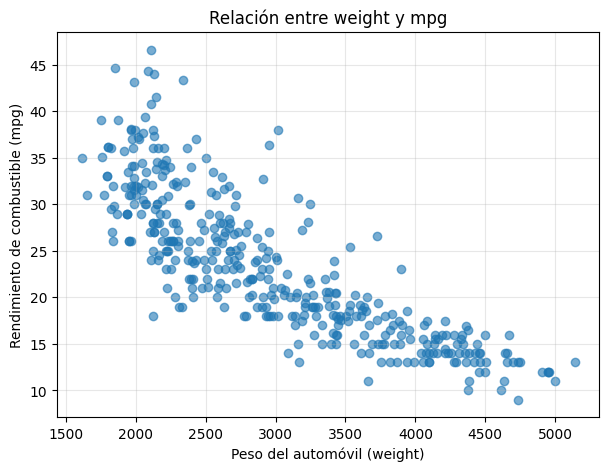

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["weight"],
    df["mpg"],
    alpha=0.6
)
plt.xlabel("Peso del automóvil (weight)")
plt.ylabel("Rendimiento de combustible (mpg)")
plt.title("Relación entre weight y mpg")
plt.grid(alpha=0.3)
plt.show()

### 4.1 Análisis del patrón observado

Observe el diagrama de dispersión entre `weight` y `mpg`.

**Pregunta:** ¿Qué tipo de relación parece existir entre ambas variables? Considere la dirección de la relación y la forma general del patrón.

## 5. Cálculo de Pearson y Spearman

Ahora calcularemos los coeficientes de correlación de **Pearson** y **Spearman** para las variables `weight` y `mpg`.

Recordemos:

- **Pearson** evalúa principalmente la intensidad de una relación lineal.
- **Spearman** evalúa la intensidad de una relación monótona utilizando los rangos de las observaciones.

In [5]:
pearson = df["weight"].corr(df["mpg"], method="pearson")
spearman = df["weight"].corr(df["mpg"], method="spearman")
print("Correlación de Pearson:", round(pearson, 4))
print("Correlación de Spearman:", round(spearman, 4))

Correlación de Pearson: -0.8322
Correlación de Spearman: -0.8756


### 5.1 Comparación de los resultados

Los coeficientes obtenidos fueron:

- Pearson: **-0.8322**
- Spearman: **-0.8756**

**Preguntas:**

1. ¿Qué indican ambos coeficientes sobre la dirección y la intensidad de la relación entre `weight` y `mpg`?
2. ¿Por qué el valor absoluto de Spearman puede ser mayor que el de Pearson en este caso?
3. Teniendo en cuenta el diagrama de dispersión, ¿cuál de los dos coeficientes considera que describe mejor el patrón observado?

## 6. Comparación de Pearson y Spearman entre variables

En el análisis anterior observamos que Pearson y Spearman pueden producir resultados diferentes dependiendo de la forma de la relación.

Ahora compararemos ambos coeficientes entre las variables numéricas del conjunto de datos para identificar relaciones donde esta diferencia sea más evidente.

In [6]:
variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]
corr_pearson = df[variables].corr(method="pearson")
corr_spearman = df[variables].corr(method="spearman")
print("Correlación de Pearson:")
display(corr_pearson.round(3))
print("\nCorrelación de Spearman:")
display(corr_spearman.round(3))

Correlación de Pearson:


,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000,-0.778,-0.805,-0.778,-0.832,0.423
cylinders,-0.778,1.000,0.951,0.843,0.898,-0.505
displacement,-0.805,0.951,1.000,0.897,0.933,-0.544
horsepower,-0.778,0.843,0.897,1.000,0.865,-0.689
weight,-0.832,0.898,0.933,0.865,1.000,-0.417
acceleration,0.423,-0.505,-0.544,-0.689,-0.417,1.000



Correlación de Spearman:


,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000,-0.823,-0.855,-0.854,-0.876,0.442
cylinders,-0.823,1.000,0.914,0.816,0.876,-0.476
displacement,-0.855,0.914,1.000,0.876,0.946,-0.499
horsepower,-0.854,0.816,0.876,1.000,0.879,-0.658
weight,-0.876,0.876,0.946,0.879,1.000,-0.405
acceleration,0.442,-0.476,-0.499,-0.658,-0.405,1.000


## 7. Segundo caso: `horsepower` y `acceleration`

En el primer análisis observamos una relación donde Spearman presentó una correlación ligeramente más fuerte que Pearson.

Ahora analizaremos la relación entre la **potencia del automóvil (`horsepower`)** y la **aceleración (`acceleration`)**.

Primero observaremos el patrón de los datos antes de interpretar los coeficientes de correlación.

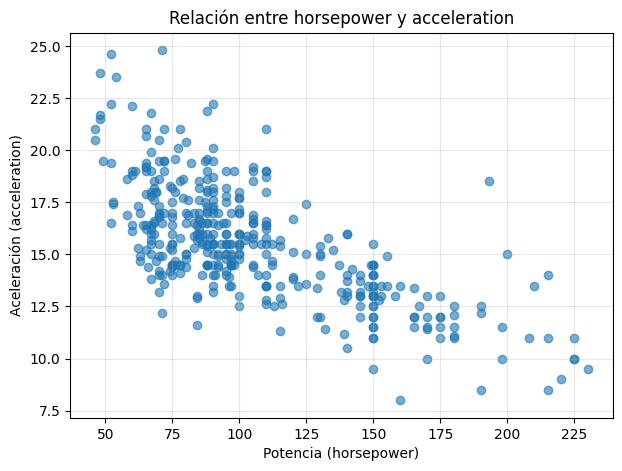

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["horsepower"],
    df["acceleration"],
    alpha=0.6
)
plt.xlabel("Potencia (horsepower)")
plt.ylabel("Aceleración (acceleration)")
plt.title("Relación entre horsepower y acceleration")
plt.grid(alpha=0.3)
plt.show()

## 8. Comparación de los coeficientes

Calcularemos los coeficientes de **Pearson** y **Spearman** para la relación entre `horsepower` y `acceleration`.

Posteriormente compararemos estos resultados con el patrón observado en el diagrama de dispersión.

In [8]:
pearson_hp_acc = df["horsepower"].corr(
    df["acceleration"],
    method="pearson"
)
spearman_hp_acc = df["horsepower"].corr(
    df["acceleration"],
    method="spearman"
)
print("Correlación de Pearson:", round(pearson_hp_acc, 4))
print("Correlación de Spearman:", round(spearman_hp_acc, 4))

Correlación de Pearson: -0.6892
Correlación de Spearman: -0.6581


### 8.1 Interpretación de los resultados

**Preguntas:**

1. ¿Qué indican ambos coeficientes sobre la relación entre `horsepower` y `acceleration`?
2. ¿Los resultados de Pearson y Spearman son considerablemente diferentes?
3. Teniendo en cuenta el gráfico y los coeficientes obtenidos, ¿qué podemos concluir sobre el tipo de relación entre estas variables?

## 9. Conclusiones del laboratorio

A partir de los análisis realizados con `weight`–`mpg` y `horsepower`–`acceleration`, responda:

1. ¿Por qué Pearson y Spearman pueden producir valores diferentes al analizar las mismas variables?
2. ¿En qué tipo de relación resulta más apropiado utilizar Pearson?
3. ¿En qué situación puede resultar más apropiado utilizar Spearman?
4. ¿Por qué es importante observar el diagrama de dispersión antes de seleccionar un coeficiente de correlación?